In [3]:
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../공유/final_cleaned_airbnb.csv')
df.shape

(19861, 60)

In [4]:
!pip install scipy
!pip install statsmodels

## 1번 통계검증 : 자치구(Borough)별 평균 수익 차이 검증 (ANOVA)
제 히트맵 자료를 보면 맨해튼이나 브루클린의 수익이 높아 보이는데, 이게 진짜 지역이 가지는 특성 때문인지 아니면 그냥 어쩌다 비싼 매물이 몇 개 섞여서 그런 건지 확인해보는게 좋을 것 같아서 선택했습니다!

가설 설정
- 귀무가설($H_0$): 뉴욕의 모든 자치구(Manhattan, Brooklyn 등) 간의 평균 수익은 차이가 없음 (한 마디로 지역은 상관없다)
- 대립가설($H_1$): 적어도 하나의 자치구의 평균 수익이 다른 구와 통계적으로 유의미한 차이가 나올 수 있음 (돈 되는 동네가 따로 있다)



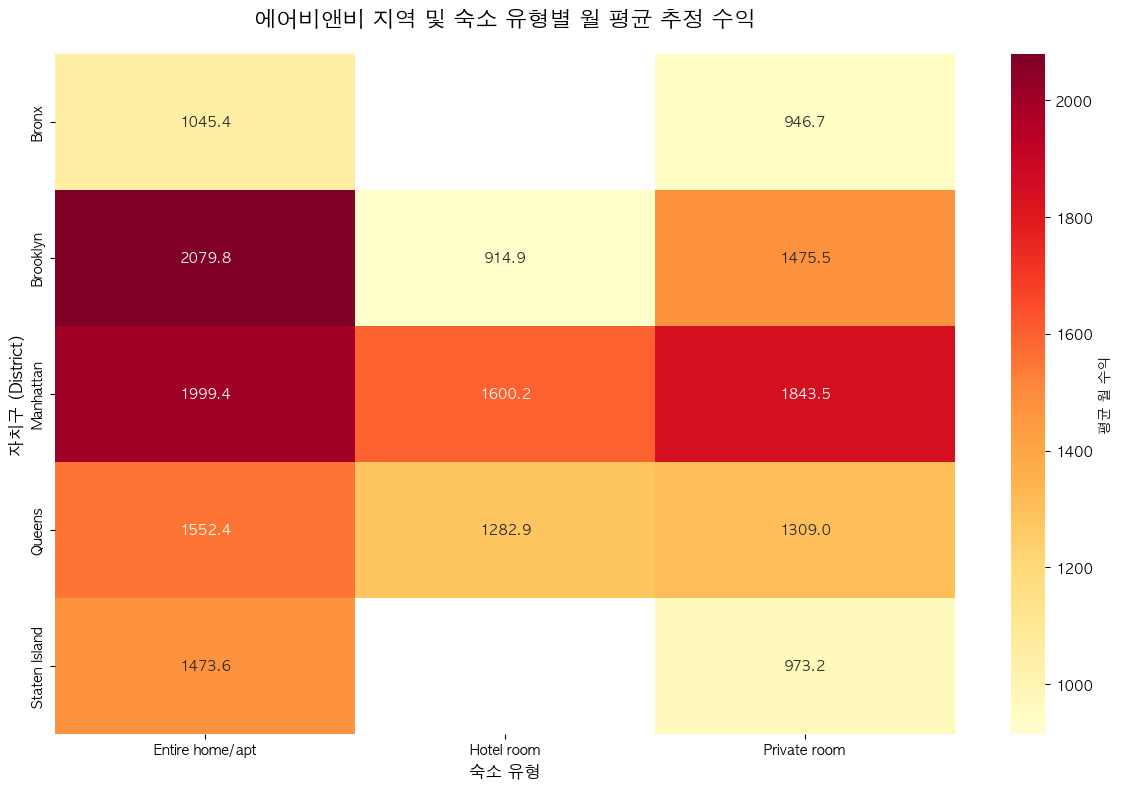

In [5]:
#지역 및 숙소 유형별 월평균 추정 수익
plt.rc('font', family='AppleGothic') #한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

#월평균 수익 계산 (연간 수익/12)
df['월평균_추정수익'] = df['estimated_revenue_l365d'] / 12

#피벗 테이블 생성
#수익이 0보다 큰 데이터만 사용해서 평균 계산
pivot_df = df[df['월평균_추정수익'] > 0].pivot_table(
    index='neighbourhood_group_cleansed', 
    columns='room_type', 
    values='월평균_추정수익', 
    aggfunc='mean'
)

#히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlOrRd", 
            cbar_kws={'label': '평균 월 수익'})

plt.title('에어비앤비 지역 및 숙소 유형별 월 평균 추정 수익', fontsize=16, pad=20)
plt.xlabel('숙소 유형', fontsize=12)
plt.ylabel('자치구 (District)', fontsize=12)

plt.tight_layout()
plt.show()
#시각화 자료를 보면 Manhattan과 Brooklyn의 월평균 수익이 다른 지역에 비해 높게 나타남

F-statistic: 51.1806
p-value: 0.0000

지역별 차이 상세 분석 (Tukey HSD)


group1,group2,meandiff,p-adj,lower,upper,reject
Bronx,Brooklyn,786.7187,0.0,532.6533,1040.7841,True
Bronx,Manhattan,956.2367,0.0,704.6114,1207.862,True
Bronx,Queens,415.2132,0.0002,147.1073,683.3192,True
Bronx,Staten Island,246.6964,0.5376,-190.9015,684.2944,False
Brooklyn,Manhattan,169.518,0.0003,58.8531,280.1829,True
Brooklyn,Queens,-371.5055,0.0,-515.7699,-227.241,True
Brooklyn,Staten Island,-540.0223,0.0008,-914.7534,-165.2912,True
Manhattan,Queens,-541.0235,0.0,-680.9459,-401.101,True
Manhattan,Staten Island,-709.5403,0.0,-1082.6213,-336.4592,True
Queens,Staten Island,-168.5168,0.7537,-552.9059,215.8723,False


/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_1191/3543536309.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='neighbourhood_group_cleansed', y='estimated_revenue_per_month',


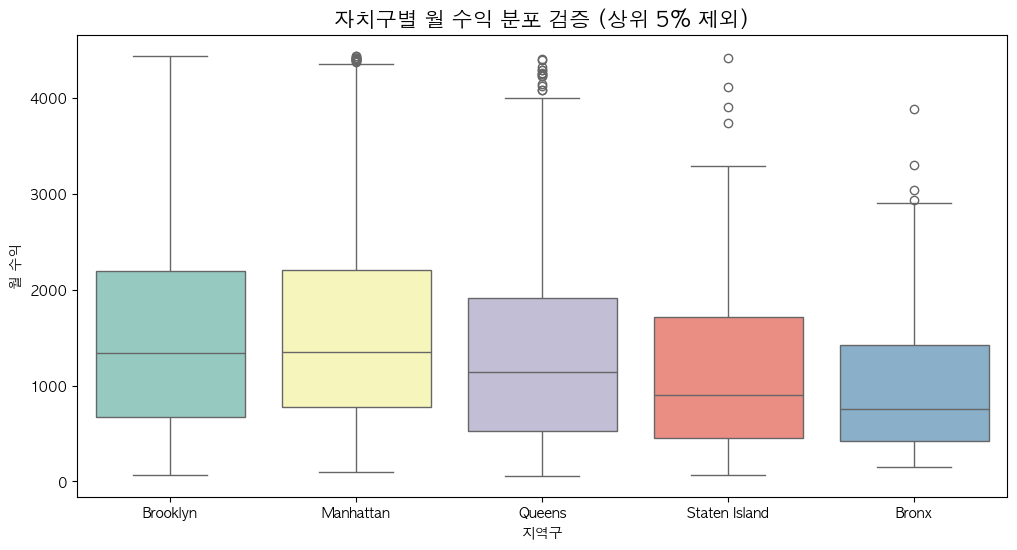

In [6]:
#월평균 수익 : 연간 수익을 12로 나눠줌
df['estimated_revenue_per_month'] = df['estimated_revenue_l365d'] / 12

#ANOVA 검증 (수익이 0인 곳은 제외하고 분석)
valid_df = df[df['estimated_revenue_per_month'] > 0]
groups = [valid_df[valid_df['neighbourhood_group_cleansed'] == g]['estimated_revenue_per_month'] for g in valid_df['neighbourhood_group_cleansed'].unique()]

f_stat, p_val = stats.f_oneway(*groups)

print(f'F-statistic: {f_stat:.4f}')
print(f'p-value: {p_val:.4f}')

#사후 분석 (어떤 동네끼리 진짜 차이나는지 확인)
tukey = pairwise_tukeyhsd(endog=valid_df['estimated_revenue_per_month'], 
                          groups=valid_df['neighbourhood_group_cleansed'], 
                          alpha=0.05)

print("\n지역별 차이 상세 분석 (Tukey HSD)")
display(tukey.summary())

#시각화 검증
plt.figure(figsize=(12, 6))
plt.rc('font', family='AppleGothic') 

#수익이 너무 높은 상위 5%는 제외하고 박스플롯 그리기 (분포를 더 잘 보기 위해서!)
limit = valid_df['estimated_revenue_per_month'].quantile(0.95)
sns.boxplot(x='neighbourhood_group_cleansed', y='estimated_revenue_per_month', 
            data=valid_df[valid_df['estimated_revenue_per_month'] < limit], palette='Set3')

plt.title('자치구별 월 수익 분포 검증 (상위 5% 제외)', fontsize=15)
plt.ylabel('월 수익')
plt.xlabel('지역구')
plt.show()

1. ANOVA 결과: 수익은 지역빨이라고 볼 수 있습니다!
p-value 수치가 0.05보다 작으면 "지역별 수익 차이는 우연이 아니다"라는 뜻이라고 볼 수 있습니다
그러므로 "뉴욕에서 에어비앤비 숙소 수익은 어느 동네에 있냐에 따라 결정된다"라는 것을 통계검증을 통해 증명한 것 입니다!

2. 사후 분석 (Tukey HSD): 누가 누구를 이겼는가?를 알 수 있습니다
- 저희가 표에서 가장 중요한 게 보아야 할 것은 **reject**와 **meandiff**입니당. reject가 True면 두 지역 사이에 진짜 차이가 있다는 뜻이고, meandiff는 그 차이가 얼마인지를 보여주는 자료이기 때문입니다.

**True로 나온 자료들만 글로서 정리 해보았습니다!**
- Manhattan vs 나머지 자치구 : 맨해튼은 모든 지역을 상대로 'True'를 띄우고 있습니당! 특히 Bronx보다는 무려 $956이나 더 벌고있어용 완전 압도적이죠

- Brooklyn vs 나머지 : 브루클린도 맨해튼을 제외한 모든 지역보다 수익이 높게 나왔습니다
맨해튼과는 약 $169 정도 차이가 나는데, 이건 생각보다? 적은 차이라고 볼 수 있습니다 (여기서 나올 수 있는 인사이트: 임대료를 생각하면 브루클린이 더 꿀일지도?)

- Queens vs Bronx: 퀸즈는 브롱스보다는 확실히($415) 더 잘 벌어요


**여기서 부터는 False 자료들 입니다!**
- Bronx vs Staten Island: reject가 False죠? 둘의 수익 차이는 통계적으로 "거기서 거기"라는 뜻으로 볼 수 있습니다

- Queens vs Staten Island : 여기도 False입니당 흠.. 수익만 놓고 보면 퀸즈나 스테이튼 아일랜드나 큰 차이가 없다고 봐도 무방할 것 같습니다

**한줄로 나온 인사이트를 요약을 해본다면, "압도적 수익을 원하면 맨해튼, 가성비와 실속을 챙기려면 브루클린이 정답임! 수익성을 원한다면 브롱스는 에바!"로 볼 수 있겠습니당**

## 2번 통계검증 : 규제 대응 방식에 따른 수익 차이 검증

제가 뉴욕 호스트들이 규제 때문에 **장기 숙박(30일 이상)** 으로 대거 전환한 것 같다는 인사이트를 냈는데, 그럼 과연 호스트들이 장기 숙박으로 바꾼 게 수익에 도움이 됐을까?해서 그 부분을 검증해보려고 합니당

1. 가설 설정
- 귀무가설($H_0$): 운영 형태(장기 vs 단기 vs 호텔)에 따른 평균 수익 차이는 없음
- 대립가설($H_1$): 운영 형태에 따라 수익에 유의미한 차이가 있으며, 특정 형태가 더 유리함

2. 검증 흐름 (제가 참여를 못해서 조금 더 이해하시기 쉬우실까 해서 넣어봤습니당..)
- 가설 방법: ANOVA (3개 그룹 비교: Residential_long_term, Residential_short_term, Hotel)

**이 가설에서 만약 장기 숙박의 수익이 단기보다 유의미하게 낮다고 나온다면, "규제 때문에 어쩔 수 없이 수익을 포기하고 생존을 택했다"는 완전한 결론을 낼 수 있을거라 판단했습니다!**

[30일 규제 집중도 분석 결과]
뉴욕 전체 매물: 19861개
30일로 설정된 매물: 15582개
전체 시장 내 비중: 78.5%


/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_1191/1438654807.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


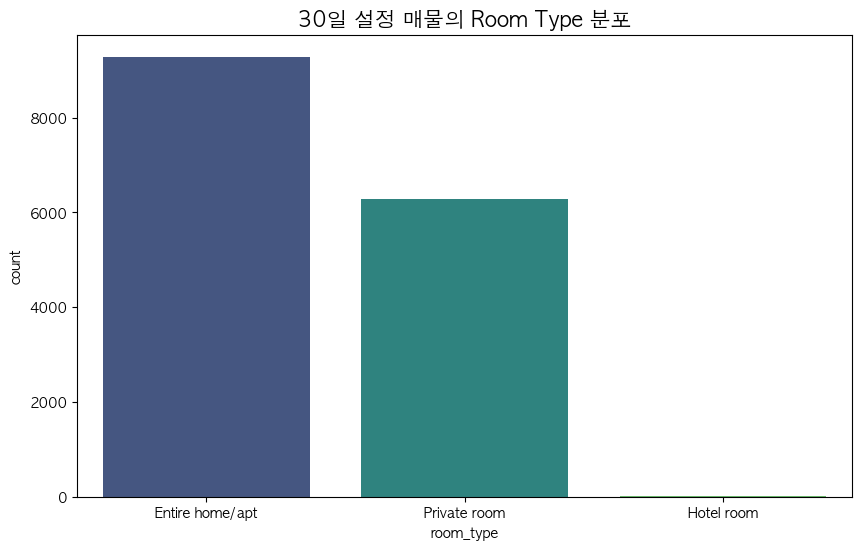

/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_1191/1438654807.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


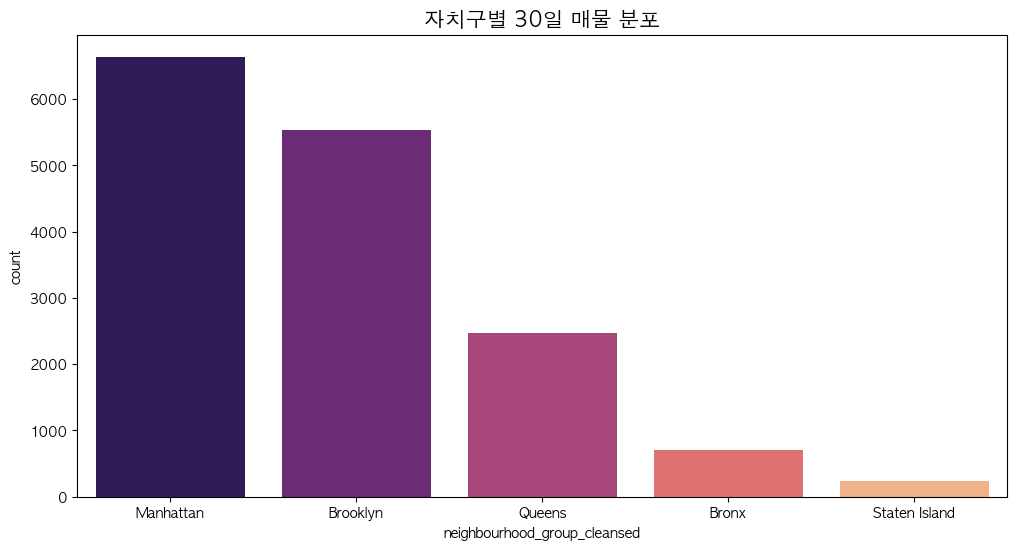

In [7]:
df_30 = df[df['minimum_nights'] == 30]
total_count = len(df)
count_30 = len(df_30)
ratio_30 = (count_30 / total_count) * 100

print(f"[30일 규제 집중도 분석 결과]")
print(f"뉴욕 전체 매물: {total_count}개")
print(f"30일로 설정된 매물: {count_30}개")
print(f"전체 시장 내 비중: {ratio_30:.1f}%")

#30일 매물의 Room Type 분포
#규제가 엄격한 'Entire home/apt'가 얼마나 많은지 보는 게 핵심
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_30, 
    x='room_type', 
    palette='viridis', 
    order=df_30['room_type'].value_counts().index
)
plt.title('30일 설정 매물의 Room Type 분포', fontsize=15)
plt.show()

#자치구별 30일 매물 현황
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_30, 
    x='neighbourhood_group_cleansed', 
    palette='magma',
    order=df_30['neighbourhood_group_cleansed'].value_counts().index
)
plt.title('자치구별 30일 매물 분포', fontsize=15)
plt.show()
#뉴욕 30일 규제 분석 브리핑
#시장의 기형적 쏠림 (78.5%)
#뉴욕 전체 매물 19,861개 중 무려 15,582개(78.5%)가 '최소 숙박 30일'로 설정
#이건 호스트들의 자발적 선택이 아니라, Local Law 18에 대응하기 위한 생존 전략임을 알 수 있음
#-> 뉴욕 에어비앤비는 이제 여행자 숙소가 아니라 장기 임대 시장으로 변했다고 볼 수 있음

In [8]:
#수익 계산 및 결측치 제거
df['temp_revenue'] = df['estimated_revenue_l365d'] / 12
valid_df = df.dropna(subset=['property_regulation_type', 'temp_revenue'])

#ANOVA 검증 (세 그룹 비교)
groups = [valid_df[valid_df['property_regulation_type'] == t]['temp_revenue'] 
          for t in valid_df['property_regulation_type'].unique()]

f_stat, p_val = stats.f_oneway(*groups)
print(f'ANOVA 결과 - F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}')

#사후 분석 (Tukey HSD) : 그렇다면 누가 제일 손해인가?
tukey_reg = pairwise_tukeyhsd(endog=valid_df['temp_revenue'], 
                              groups=valid_df['property_regulation_type'], 
                              alpha=0.05)
print("\n--- 규제 유형별 수익 차이 상세 분석 ---")
display(tukey_reg.summary())

ANOVA 결과 - F-statistic: 1136.3978, p-value: 0.0000

--- 규제 유형별 수익 차이 상세 분석 ---


group1,group2,meandiff,p-adj,lower,upper,reject
Hotel,Residential_long_term,-668.3972,0.0,-764.7517,-572.0426,True
Hotel,Residential_short_term,868.17,0.0,748.0977,988.2423,True
Residential_long_term,Residential_short_term,1536.5672,0.0,1457.9805,1615.1538,True


1. Anova 결과 : "규제 대응 방식이 수익을 결정한다!" (p-value: 0.0000)
- p-value가 0.05보다 훨씬 작게 나왔죵? 이건 운영 방식에 따른 수익 차이는 절대로 우연이 아닐 것이라고 제가 세운 가설이 제대로 검증이 됐다고 볼 수 있습니다. 규제를 피하기 위해 선택한 운영 방식이 수익에 엄청난 영향을 주고 있다는 게 통계로서 검증을 한거죠..

2. 사후 분석 (Tukey HSD): "누가 가장 큰 타격을 입었을까?"
표에서 reject가 전부 True인 거 보이시나용
세 그룹의 수익성?이 서로 완전히 다르다고 볼 수 있습니다! 

- **Hotel vs Residential_long_term(장기)**
meandiff: -668.4
규제를 피해서 30일 이상 장기 숙박으로 돌린 숙소들은 호텔보다 한 달에 평균 $668이나 덜 벌고 있는 것을 볼 수 있습니다!

- **Residential_long_term(장기) vs Residential_short_term(단기)**
meandiff: 1536.5
이게 좀 잘된?좋은? 검증인 것 같습니당(개인적으로) 
규제를 뚫고(또는 지키며) 단기 숙박을 유지하는 곳들은 장기 숙박보다 무려 $1,536이나 더 벌고 있는 것을 알 수 있었어용
규제를 따라서 장기로 돌리는 순간 수익이 반토막 이상난다..

- **Hotel vs Residential_short_term(단기)**
meandiff: 868.1
의외로 호텔보다 합법적 단기 숙소(Residential_short_term)의 수익이 더 높게 나왔어용 
이건 호텔보다 에어비앤비 단기 숙소의 객단가나 선호도가 더 높을 수 있다는 걸 시사한다고 볼 수 있겠습니다

**뉴욕 호스트들이 78.5%나 장기 숙박으로 갈아탄 건 수익이 좋아서가 아니라, '수익을 포기하고서라도 규제 속에서 숙소 운영을 하겠다'였다는 것을 알 수 있었습니다**

## 3번 통계검증 : 숙소 타입별 수요(월간 리뷰 수) 차이 검증

단순히 수익만 보는 게 아니라, **"사람들이 실제로 얼마나 자주 예약하고 머무는지(수요)"** 를 월간 리뷰 수를 통해 검증해보려 합니당

1. 가설설정
- 귀무가설($H_0$): 숙소 타입(Entire home vs Private room) 간의 평균 월간 리뷰 수 차이는 없음
- 대립가설($H_1$): 숙소 타입에 따라 평균 월간 리뷰 수에 유의미한 차이가 있음

2. 검증 흐름
- 가설 방법: T-검정 (Independent T-test, 두 그룹 비교)

/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_1191/2727033536.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='reviews_per_month', data=filtered_df, palette='Set2')


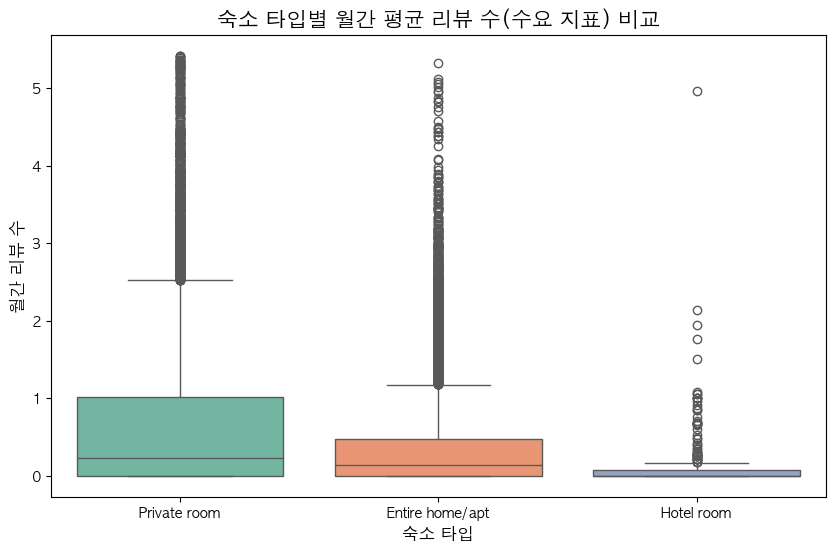

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='AppleGothic') 

#이상치를 제외한 데이터 필터링 (너무 리뷰가 많은 상위 1% 제외)
limit_review = df['reviews_per_month'].quantile(0.99)
filtered_df = df[df['reviews_per_month'] < limit_review]

#시각화 (Boxplot + Stripplot 합치기)
plt.figure(figsize=(10, 6))

#박스플롯으로 분포 확인
sns.boxplot(x='room_type', y='reviews_per_month', data=filtered_df, palette='Set2')

#실제 데이터 점들을 활용하여 밀집도 확인 (이건 llm에게 가독성을 위해 물어본 내용입니다!)
# sns.stripplot(x='room_type', y='reviews_per_month', data=filtered_df, color='black', alpha=0.1)

plt.title('숙소 타입별 월간 평균 리뷰 수(수요 지표) 비교', fontsize=15)
plt.xlabel('숙소 타입', fontsize=12)
plt.ylabel('월간 리뷰 수', fontsize=12)
plt.show()

In [10]:
# T-검정 (가장 많이 쓰이는 두 유형만 비교)
home = df[df['room_type'] == 'Entire home/apt']['reviews_per_month'].dropna()
private = df[df['room_type'] == 'Private room']['reviews_per_month'].dropna()

t_stat, p_val_t = stats.ttest_ind(home, private, equal_var=False)

print(f'T-검정 결과 - t-statistic: {t_stat:.4f}, p-value: {p_val_t:.4f}')

T-검정 결과 - t-statistic: -23.2589, p-value: 0.0000


1. **p-value가 0.0000**
이 결과를 통계학적으로 본다면 **"이 결과가 우연일 확률은 0%에 가깝다"** 는 뜻으로 볼 수 있습니다
(왜 우연이냐? p-value가 0.0000이 나왔다는 건, 이게 우연일 확률이 0.0001%도 안 된다라는 뜻이기 때문입니다. 즉, 우연이라고 하기엔 데이터가 너무 극단적으로 차이를 보여주고 있다는거죵)
즉, 숙소 타입에 따른 인기도 차이는 확실하다고 볼 수 있습니다

2. **t-statistic이 -23.25나 된다는 것**
이 숫자는 두 그룹이 얼마나 멀리 떨어져 있는지를 보여주는 거리? 같은거라고 생각해주시면 됩니당
보통 t-값이 2나 -2만 넘어도 두 값이 다르다라고 본대요..(튜터님 설명참조)
근데 제가 검증해본 결과에서는 -23.25가 나왔잖아용 
이건 두 그룹이 거의 서울이랑 부산만큼 떨어져 있다고 봐주시면 될 것 같아요

**그래서 결론!! 통계적으로 나온 -23.25이라는 수치는, 뉴욕 에어비앤비의 실질적인 수요가 'Entire home/apt'가 아닌 'Private room'에 압도적으로 쏠려 있음을 완벽히 증명해준다고 볼 수 있겠습니당**


## 4번 통계검정 : 동네별 매물 수와 점유율의 관계 (공급과 수요)

제가 전처리/시각화 과정에서 상위 10개 동네의 매물 현황(공급)을 뽑았봤는데,
그러면 과연 매물이 많은 동네가 과연 점유율도 높을까?하는 의문점이 들어 검증을 한 번 해보았습니당

1. 가설설정
- 귀무가설($H_0$): 매물 상위 동네와 하위 동네의 평균 점유율(리뷰 수)은 차이가 없음
- 대립가설($H_1$): 매물 상위 동네와 하위 동네의 평균 점유율은 통계적으로 유의미한 차이가 있음

2. 검증흐름
- 가설방법 : 독립표본 t-검정 (Independent t-test)

In [12]:
#상위 10개 동네와 해당 borough를 함께 보여주는 테이블 생성
#동네별로 묶어서 Borough 정보를 같이 가져오기
top10_with_borough = df.groupby(['neighbourhood_cleansed', 'neighbourhood_group_cleansed']).size().reset_index(name='count')

#매물 수 기준으로 내림차순 정렬해서 상위 10개만 뽑기
top10_result = top10_with_borough.sort_values(by='count', ascending=False).head(10)

print("[상위 10개 동네 및 소속 Borough]")
print(top10_result)

[상위 10개 동네 및 소속 Borough]
    neighbourhood_cleansed neighbourhood_group_cleansed  count
12      Bedford-Stuyvesant                     Brooklyn   1362
129                Midtown                    Manhattan   1206
201        Upper East Side                    Manhattan    997
97          Hell's Kitchen                    Manhattan    954
96                  Harlem                    Manhattan    901
202        Upper West Side                    Manhattan    877
214           Williamsburg                     Brooklyn    800
27                Bushwick                     Brooklyn    690
52           Crown Heights                     Brooklyn    555
65            East Village                    Manhattan    459


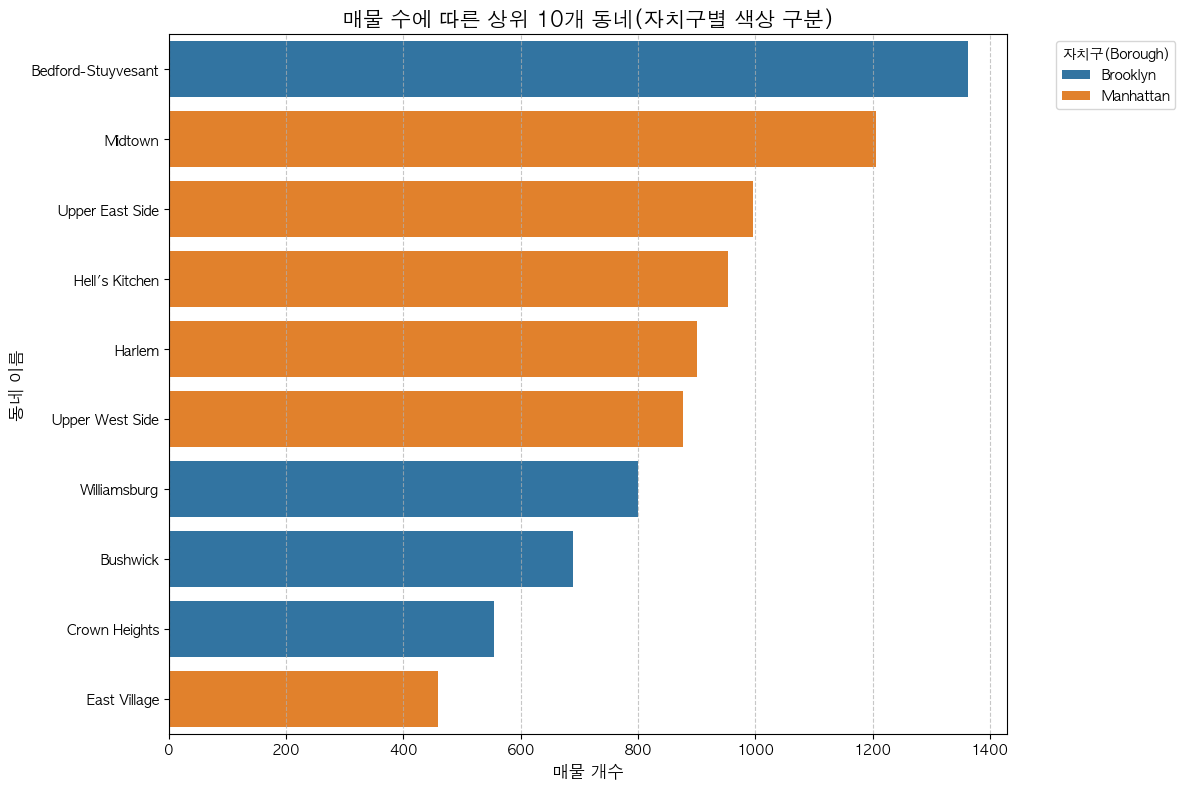

In [14]:
plt.rc('font', family='AppleGothic') 

#데이터 : 아까 만든 top10_result 활용
plt.figure(figsize=(12, 8))

#막대 그래프(x축: 매물 수, y축: 동네이름)
sns.barplot(
    data=top10_result, 
    x='count', 
    y='neighbourhood_cleansed', 
    hue='neighbourhood_group_cleansed',
    dodge=False #dodge를 사용하면 막대가 갈라지지 않게 설정
)

plt.title('매물 수에 따른 상위 10개 동네(자치구별 색상 구분)', fontsize=15)
plt.xlabel('매물 개수', fontsize=12)
plt.ylabel('동네 이름', fontsize=12)
plt.legend(title='자치구(Borough)', bbox_to_anchor=(1.05, 1), loc='upper left') 
#범례 위치를 보기 좋게 조절
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from scipy import stats

#동네별 매물 수 계산 및 그룹핑
neighborhood_counts = df['neighbourhood_cleansed'].value_counts()
top_10_neighborhoods = neighborhood_counts.head(10).index

#제가 임의로 그룹을 할당해주었습니다! -> 상위 10개 동네는 'High', 나머지는 'Low'
df['supply_group'] = df['neighbourhood_cleansed'].apply(lambda x: 'High' if x in top_10_neighborhoods else 'Low')

#그룹별 점유율(reviews_per_month) 데이터 추출
#결측치는 0으로 채우거나 제거(여기서는 제거로 진행했어요)
#이유 : 결측치를 0으로 채우면 실제로 리뷰가 없는 매물과 구분이 안 되어서 분석이 왜곡될 수 있기 때문에
high_supply = df[df['supply_group'] == 'High']['reviews_per_month'].dropna()
low_supply = df[df['supply_group'] == 'Low']['reviews_per_month'].dropna()

#등분산성 검정 (Levene's test) : t-test 전제 조건 확인
stat, p_levene = stats.levene(high_supply, low_supply)
print(f"등분산성 검정 p-value: {p_levene:.4f}")

#t-검정 실시
#등분산성이 깨졌을 경우를 대비해 equal_var 설정을 고려 (p_levene < 0.05면 False)
t_stat, p_value = stats.ttest_ind(high_supply, low_supply, equal_var=(p_levene > 0.05))

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("결과: 통계적으로 유의미한 차이가 있음!(귀무가설 기각)")
else:
    print("결과: 통계적으로 유의미한 차이가 없음(귀무가설 채택)")
#여기서 점유율을 월간 리뷰수로 설정 그 이유는 
#에어비앤비는 실제로 예약하고 머문 사람만 리뷰를 남길 수 있음
#그래서 리뷰가 많다는 건 그만큼 손님이 많이 다녀갔다는 증거로 활용 가능
#또한 월간 리뷰수는 최근 활성도를 보여주기 때문에, 지금 이 숙소가 얼마나 잘 나가는지(점유율) 판단하기에 좋다고 판단

등분산성 검정 p-value: 0.0000
t-statistic: -10.1195
p-value: 0.0000
결과: 통계적으로 유의미한 차이가 있음!(귀무가설 기각)


1. t-statistic이 마이너스 값이 나왔어용.. 천천히 설명을 해보자면
제가 비교 순서?를 잡아줄 때 **(High 그룹의 평균 점유율) - (Low 그룹의 평균 점유율)** 이렇게 잡아줬는데,
결과가 -10.1195라는 건, 뒤에 있는 Low 그룹의 평균이 훨씬 크기 때문에 뺐을 때 마이너스 값이 나온거에용
만약 두 그룹이 비슷했다면 0에 가까웠을 거고,High 그룹이 훨씬 높았다면 플러스(+) 값이 였겠죠

쉽게 설명을 해보자면
- High (매물 많은 동네): 강남처럼 식당이 겁나 많은 곳이라고 생각해주시면 됩니당 
사람은 많지만, 내 옆집도 뒷집도 다 똑같은 음식을 팔고, 손님은 분산되고, 한 식당당 돌아가는 손님 수는 생각보다 적을 수 있다고 볼 수 있어요 (굳이 정의를 하자면 레드오션!)

- Low (매물 적은 동네): 작은 동네에 숨겨진 맛집 같은 곳이죵 
숙소는 몇 개 없는데, 그 동네에 가야 하는 사람들은 반드시 그 숙소를 예약해야 하겠죠 
그래서 숙소 하나하나가 예약으로 꽉 차게 됩니다 (이것도 정의를 하자명 블루오션!)

**즉, t-statistic이 -10이라는 건 "공급이 적은 동네의 숙소들이 공급이 많은 동네보다 통계적으로 압도적으로 바삐 돌아간다"는 걸 증명해볼 수 있었습니당**


2. 등분산성 p-value 0.0000
이 값으로 저희는 **"두 동네의 격차 양상이 다르다"**는 것을 알 수 있겠죠?
High 그룹: 잘되는 집은 엄청 잘되고 안되는 집은 아예 안되는 식으로 격차가 엄청 클 수 있음
Low 그룹: 전반적으로 다 비슷비슷하게 예약이 잘 들어올 가능성 높음


**한 문장으로 '매물이 너무 많은 유명한 동네보다, 매물이 적당히 적은 동네에 숙소를 차리는 게 개별 점유율을 높이는 데 훨씬 유리하다'는 인사이트를 내 볼 수 있겠습니다**